<a href="https://colab.research.google.com/github/deboraluz/deboraluz/blob/main/Profissao_Cientista_de_Dados_M14_Pratique_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MÓDULO 14 - Exercício**
# Pré Processamento dos Dados - A primeira etapa Pré Modelagem

Para nossa atividade usaremos uma base de churn também, porém essa base não diz respeito a serviços bancários e sim serviços de internet, telefone e tv - Telecomunicação.

Vamos realizar aqui as etapas de limpeza e tratamento de dados vistos durante a aula, porém aplicados a essa base nova.

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [12]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CHURN_TELECON_MOD08_TAREFA.csv", delimiter=';')

df.head(10)

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),NaN,1840.75,No
4,9237-HQITU,NaN,0,No,No,2,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,151.65,Yes
5,9305-CDSKC,NaN,0,No,No,8,Yes,Fiber optic,No,No,Yes,Month-to-month,Electronic check,NaN,820.50,NaN
6,1452-KIOVK,NaN,0,No,Yes,22,Yes,Fiber optic,No,No,Yes,Month-to-month,Credit card (automatic),NaN,1949.40,NaN
7,6713-OKOMC,NaN,0,No,No,10,No,DSL,Yes,No,No,Month-to-month,Mailed check,NaN,301.90,NaN
8,7892-POOKP,NaN,0,Yes,No,28,Yes,Fiber optic,No,Yes,Yes,Month-to-month,Electronic check,NaN,3046.05,NaN
9,6388-TABGU,NaN,0,No,Yes,62,Yes,dsl,Yes,No,No,One year,Bank transfer (automatic),NaN,3487.95,NaN


Legenda dos dados:

*   **CustomerID** : Esse é o ID único de cada cliente nosso da rede de produtos de telecomunicação.

*   **Genero** : O genero dos nossos clientes.

*   **Idoso** : Se nosso cliente tem acima de 60 anos ou não. (Sim = 1 | Não = 0)

*   **Casado** : Se nosso cliente é casado ou não.

*   **Dependents** : Se cliente tem dependentes.

*   **Tempo_como_Cliente** : Tempo em meses que nosso cliente está com a nossa empresa.

*   **PhoneService** : Se ele contratou serviço telefônico com a nossa empresa.

*   **Servico_Internet** : Qual o tipo de serviço de internet contratado.

*   **Servico_Seguranca** : Se ele contratou serviço de segurança com a nossa empresa.

*   **Suporte_Tecnico** : Se já acionou o suporte técnico.

*   **StreamingTV** : Se ele contratou serviço de streaming para TV.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **PaymentMethod** : Forma de Pagamento.

*   **Pagamento_Mensal** : Quanto o cliente pagava mensalmente.

*   **Total_Pago** : Total já pago pelo cliente para nossa companhia.

*   **Churn** : Nossa coluna mais importante, se nosso cliente nos abandonou ou não.




# 1 - Carregue a base, verifique se os tipos de dados estão de acordo com cada coluna e caso não estejam realize a transformação dos tipos de dados.

In [4]:
df.dtypes

,0
customerID,object
Genero,object
Idoso,int64
Casado,object
Dependents,object
Tempo_como_Cliente,int64
PhoneService,object
Servico_Internet,object
Servico_Seguranca,object
Suporte_Tecnico,object


Nessa etapa não encontrei nenhum "tipo de dado" fora do que deveria ser.

# 2 - Esse exercício faremos por etapas:
A) Verifique se temos colunas com dados faltantes e traga a % dos dados faltantes por coluna.

In [5]:
faltantes = pd.DataFrame({
    'Quantidade': df.isna().sum(),
    'Percentual': df.isna().mean() * 100
})

faltantes = faltantes.sort_values('Percentual', ascending=False)

faltantes

,Quantidade,Percentual
PhoneService,1482,59.28
Pagamento_Mensal,325,13.00
Genero,12,0.48
Churn,5,0.20
Casado,0,0.00
Dependents,0,0.00
Idoso,0,0.00
customerID,0,0.00
Servico_Internet,0,0.00
Tempo_como_Cliente,0,0.00


B) Exclua nessa etapa as linhas das colunas com dados faltantes que você analisar que esse método é o ideal. Justifique o motivo de estar excluindo essas linhas.

In [6]:
df.drop('PhoneService', axis=1, inplace=True)

A coluna PhoneService foi excluída por apresentar 59,28% de valores ausentes. Como mais da metade dos registros não possui essa informação, o preenchimento desses valores poderia introduzir uma distorção significativa nos dados. A exclusão da coluna é mais adequada do que excluir as linhas, pois a remoção das linhas faria com que uma parcela muito grande da base fosse perdida.

In [8]:
df.dropna(subset=['Churn'], inplace=True)

As 5 linhas com valores ausentes na variável Churn foram excluídas porque essa variável representa o resultado que será utilizado posteriormente na modelagem. Não seria adequado imputar um valor arbitrário para o Churn, pois isso poderia criar informações incorretas sobre o comportamento dos clientes.

C) Nessa etapa substitua pela média, mediana ou moda as linhas das colunas com valores faltantes que você analisou e entendeu que esse era o melhor método. Não se esqueça de justificar sua escolha.

**Dica variáveis numéricas:** Não se esqueça de verificar a distrbuição dos dados, média e mediana.

**Dica variáveis categóricas:** Caso precise substituir uma variável categórica utilize um gráfico de barras para verificar a que mais aparece e utilizar ela na substituição.
Ou você pode optar por excluir a coluna, mas justifique sua escolha.

Caso opte por substituir você pode utilizar a função fillna:
df['SUACOLUNA'].fillna("VALOR QUE SUBSTITUIRA O NULO", inplace=True)
Ela funcionará como a replace.

In [9]:
df['Genero'].value_counts()

,count
Genero,
Male,1265
Female,1212
M,4
f,4
F,3


In [10]:
df['Genero'] = df['Genero'].replace({
    'M': 'Male',
    'f': 'Female',
    'F': 'Female'
})

In [14]:
df['Genero'] = df['Genero'].fillna(df['Genero'].mode()[0])

In [15]:
print('Média:', df['Pagamento_Mensal'].mean())
print('Mediana:', df['Pagamento_Mensal'].median())

Média: 65.60756321839081
Mediana: 71.45


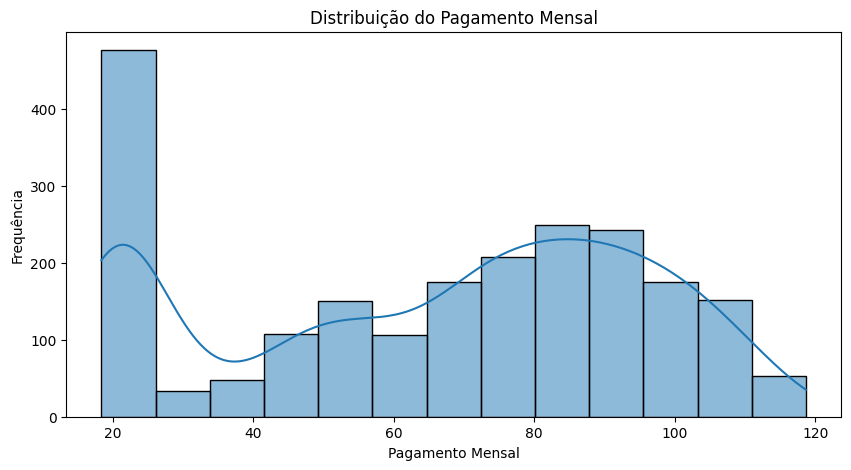

In [16]:
plt.figure(figsize=(10, 5))

sns.histplot(df['Pagamento_Mensal'], kde=True)

plt.title('Distribuição do Pagamento Mensal')
plt.xlabel('Pagamento Mensal')
plt.ylabel('Frequência')

plt.show()

In [22]:
df['Pagamento_Mensal'] = df['Pagamento_Mensal'].fillna(df['Pagamento_Mensal'].median())

Os valores ausentes da variável Pagamento_Mensal foram substituídos pela mediana, pois essa variável numérica pode apresentar valores extremos que influenciam a média. A mediana é menos sensível a outliers e, portanto, representa melhor um valor típico da distribuição.

# 3 - Verifique se encontramos valores digitados incorretamente, ou com letras maiusculas ou minusculas, ou até mesmo mesmos valores porém escritos de forma dirente e corrija.

In [24]:
df['Servico_Internet'] = df['Servico_Internet'].replace({
    'dsl': 'DSL'
})
df['Servico_Internet'].value_counts()

,count
Servico_Internet,
Fiber optic,1127
DSL,845
No,528


A coluna "genero" também possuia itens digitados incorretamente, porém foram corrigidos no exercício 2 junto com a correção dos dados faltantes.

# [EXTRA] 4 - Caso deseje, para manter um padrão na sua base, renomeie as colunas ou deixando em português, ou inglês.

In [29]:
df.rename(columns={
    'Genero': 'gender',
    'Casado': 'married',
    'Servico_Internet': 'internet_service',
    'Servico_Seguranca': 'security_service',
    'Suporte_Tecnico': 'technical_support',
    'Tipo_Contrato': 'contract_type',
    'Pagamento_Mensal': 'monthly_payment',
    'Total_Pago': 'total_paid',
    'Tempo_como_Cliente': 'time_as_customer',
    'Idoso': 'senior_citizen'
}, inplace=True)

df.head(2)

,customerID,gender,senior_citizen,married,Dependents,time_as_customer,PhoneService,internet_service,security_service,technical_support,StreamingTV,contract_type,PaymentMethod,monthly_payment,total_paid,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
